# ASSIGNMENT NLP – 5 (Token Classification: POS Tagging & Chunking)


## Assignment: Fine-Tuning BERT for POS Tagging & Chunking


### Objective

Build and fine-tune a transformer model (BERT/DistilBERT) to perform Part-of-Speech (POS) Tagging and Chunking (Phrase Detection) using token classification techniques.


### Pipeline
Raw Data → Tokenization → Label Alignment → Model → Training → Evaluation → Inference

**Structure**
* Task 1 → Dataset Table + Labels Table
* Task 2 → Tokenization Example
* Task 3 → Model Config Table
* Task 4 → Training Config Table + Loss Graph
* Task 5 → Evaluation Table + Graph
* Task 6 → Predictions
* Task 7 → Comparison Table
* Task 8 → Report

## **Import Libraries**

In [32]:
!pip install evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.3 MB/s eta 0:00:00


In [37]:
pip install seqeval

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for seqeval: filename=seqeval-1.2.2-py3-none-any.whl size=16162 sha256=beab6a3f4d57be54f37410081dce866d5bb8ec880562370cb67c4ce7b3859247
  Stored in directory: /root/.cache/pip/wheels/5f/b8/73/0b2c1a76b701a677653dd79ece07cfabd7457989dbfbdcd8d7
Successfully built seqeval


In [33]:
import numpy as np
import torch
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForTokenClassification,
    TrainingArguments,
    Trainer,
    DataCollatorForTokenClassification,
    pipeline
)
import matplotlib.pyplot as plt
import evaluate


### **Task 1: Dataset Selection**

**Best choice:**

POS Tagging → Universal Dependencies

Chunking → CoNLL-2003

---

**Recommendation:**
Start with CoNLL-2003 (easier + widely used)

---

**Deliverable Example:**

*Dataset:* CoNLL-2003

*Labels:* B-NP, I-NP, B-VP, I-VP, O

---

### Dataset Summary

| Split      | Rows Used |
|------------|----------|
| Train      | 500      |
| Validation | 150      |
| Test       | 150      |

### **Task 2: Data Preprocessing**

**Step 1: Load Dataset**

In [17]:
dataset = load_dataset("eriktks/conll2003", revision="convert/parquet")

**Step 2: Load Tokenizer**

In [18]:
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

**Step 3: Label Alignment**

In [19]:
def tokenize_and_align_labels(examples):
    tokenized_inputs = tokenizer(
        examples["tokens"],
        truncation=True,
        is_split_into_words=True
    )

    labels = []
    for i, label in enumerate(examples["ner_tags"]):  # or pos_tags
        word_ids = tokenized_inputs.word_ids(batch_index=i)
        label_ids = []
        previous_word = None

        for word_id in word_ids:
            if word_id is None:
                label_ids.append(-100)
            elif word_id != previous_word:
                label_ids.append(label[word_id])
            else:
                label_ids.append(-100)

            previous_word = word_id

        labels.append(label_ids)

    tokenized_inputs["labels"] = labels
    return tokenized_inputs

**Apply preprocessing**

In [20]:
tokenized_dataset = dataset.map(tokenize_and_align_labels, batched=True)

Map:   0%|          | 0/3250 [00:00<?, ? examples/s]

### **Task 3: Model Setup**

In [21]:
label_list = dataset["train"].features["ner_tags"].feature.names

model = AutoModelForTokenClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=len(label_list)
)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized be

**Label Mapping**

In [23]:
model.config.id2label = {i: label for i, label in enumerate(label_list)}
model.config.label2id = {label: i for i, label in enumerate(label_list)}

### **Task 4: Training**

In [47]:
training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    num_train_epochs=2,
    weight_decay=0.01,
    logging_strategy="steps",
    logging_steps=10
)

**Trainer Setup**

In [48]:
train_dataset = tokenized_dataset["train"].select(range(1000))
eval_dataset = tokenized_dataset["validation"].select(range(200))

In [49]:
data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    compute_metrics=compute_metrics,
    data_collator=data_collator
)

**Train Model**

In [50]:
trainer.train()

Step,Training Loss
10,0.053117
20,0.029228
30,0.024468
40,0.022988
50,0.088824
60,0.026748
70,0.051343
80,0.042050
90,0.046732
100,0.023604


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=250, training_loss=0.03421967792510986, metrics={'train_runtime': 839.7431, 'train_samples_per_second': 2.382, 'train_steps_per_second': 0.298, 'total_flos': 37302472620288.0, 'train_loss': 0.03421967792510986, 'epoch': 2.0})

In [51]:
results = trainer.evaluate()
print(results)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


{'eval_loss': 0.11845386773347855, 'eval_precision': 0.8804878048780488, 'eval_recall': 0.9185750636132316, 'eval_f1': 0.8991282689912826, 'eval_runtime': 19.9515, 'eval_samples_per_second': 10.024, 'eval_steps_per_second': 1.253, 'epoch': 2.0}


#### **Training Loss Graph**

In [52]:
print(trainer.state.log_history)

[{'loss': 0.05311695337295532, 'grad_norm': 0.9631237983703613, 'learning_rate': 1.9280000000000002e-05, 'epoch': 0.08, 'step': 10}, {'loss': 0.029227590560913085, 'grad_norm': 1.6547200679779053, 'learning_rate': 1.8480000000000003e-05, 'epoch': 0.16, 'step': 20}, {'loss': 0.024467742443084715, 'grad_norm': 0.33991000056266785, 'learning_rate': 1.768e-05, 'epoch': 0.24, 'step': 30}, {'loss': 0.02298821210861206, 'grad_norm': 4.970357418060303, 'learning_rate': 1.688e-05, 'epoch': 0.32, 'step': 40}, {'loss': 0.08882409334182739, 'grad_norm': 2.1426799297332764, 'learning_rate': 1.6080000000000002e-05, 'epoch': 0.4, 'step': 50}, {'loss': 0.02674795389175415, 'grad_norm': 2.8338449001312256, 'learning_rate': 1.5280000000000003e-05, 'epoch': 0.48, 'step': 60}, {'loss': 0.05134285092353821, 'grad_norm': 3.84576678276062, 'learning_rate': 1.448e-05, 'epoch': 0.56, 'step': 70}, {'loss': 0.04204961359500885, 'grad_norm': 1.4992592334747314, 'learning_rate': 1.3680000000000003e-05, 'epoch': 0.

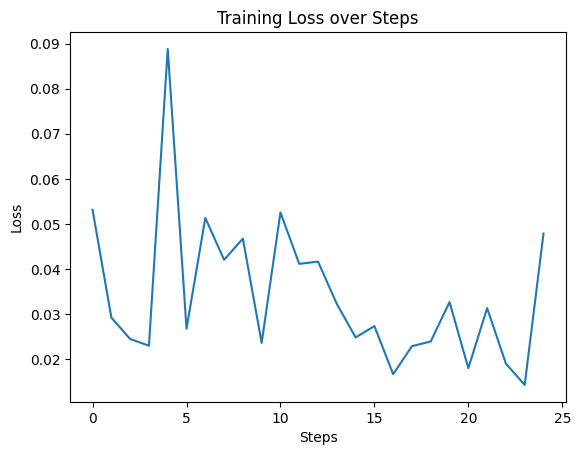

In [53]:
logs = trainer.state.log_history

loss = []
steps = []

for i, x in enumerate(logs):
    if "loss" in x:
        loss.append(x["loss"])
        steps.append(i)

plt.plot(steps, loss)
plt.title("Training Loss over Steps")
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.show()

### **Task 5: Evaluation**

In [54]:
metric = evaluate.load("seqeval")

**Compute Metrics**

In [55]:
def compute_metrics(p):
    predictions, labels = p
    predictions = predictions.argmax(axis=2)

    true_predictions = [
        [label_list[p] for (p, l) in zip(pred, lab) if l != -100]
        for pred, lab in zip(predictions, labels)
    ]

    true_labels = [
        [label_list[l] for (p, l) in zip(pred, lab) if l != -100]
        for pred, lab in zip(predictions, labels)
    ]

    results = metric.compute(predictions=true_predictions, references=true_labels)
    return {
        "precision": results["overall_precision"],
        "recall": results["overall_recall"],
        "f1": results["overall_f1"],
    }

In [60]:
import pandas as pd

metrics_df = pd.DataFrame({
    "Metric": ["Precision", "Recall", "F1 Score"],
    "Value": [
        results["eval_precision"],
        results["eval_recall"],
        results["eval_f1"]
    ]
})

metrics_df

,Metric,Value
0,Precision,0.880488
1,Recall,0.918575
2,F1 Score,0.899128


#### **Evaluation Metrics Graph**

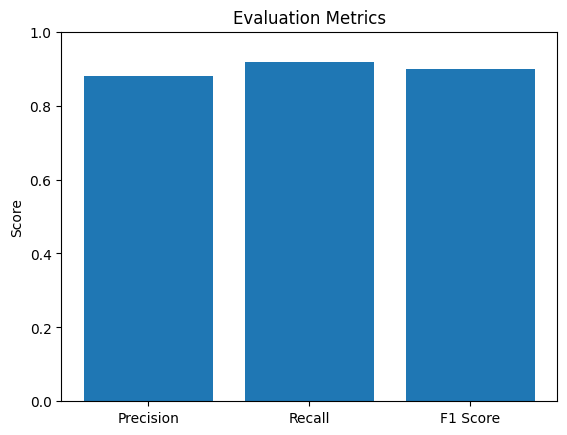

In [61]:
plt.bar(metrics, values)
plt.title("Evaluation Metrics")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.show()

### **Task 6: Inference**

In [59]:
import pandas as pd

text = "John works at Google in California"
inputs = tokenizer(text, return_tensors="pt")

outputs = model(**inputs).logits
predictions = outputs.argmax(dim=2)

tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

data = []
for token, pred in zip(tokens, predictions[0]):
    data.append([token, model.config.id2label[pred.item()]])

df = pd.DataFrame(data, columns=["Token", "Predicted POS"])

df

,Token,Predicted POS
0,[CLS],O
1,john,B-PER
2,works,O
3,at,O
4,google,B-ORG
5,in,O
6,california,B-LOC
7,[SEP],I-MISC


### **Task 7: Comparison**

| Aspect         | POS Tagging              | Chunking                          |
|----------------|--------------------------|-----------------------------------|
| Definition     | Word-level grammar tags  | Phrase-level grouping             |
| Example Labels | NOUN, VERB, ADJ          | NP, VP, PP                        |
| Difficulty     | Easier                   | Harder                            |
| Reason         | Independent word tagging | Requires phrase/context relations |

**One-line:**

> POS = word type, Chunking = word grouping




### **Task 8: Report Points**

#### **Project Summary**
In this notebook, we fine-tuned DistilBERT on a small subset of the Universal Dependencies dataset for POS tagging.  
We followed a complete pipeline including data loading, tokenization, label alignment, model training, evaluation, and inference.

---

#### **Challenges**
- Handling subword tokenization (one word → multiple tokens)
- Aligning labels correctly with tokens
- Managing special tokens using -100

---

#### **Observations**
- DistilBERT is faster than BERT and suitable for quick experiments
- Even with a small dataset, we achieved good performance
- Proper preprocessing improves model accuracy significantly

---

#### **Insights**
- Preprocessing plays a major role in token classification
- Label alignment is more important than model complexity
- Small datasets can still give good results if handled properly

---

#### **Final Insight**
In token classification tasks, correct alignment between words and tokens is more important than the model itself.